In [1]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as mtransforms
import matplotlib.gridspec as gridspec
from scipy.interpolate import Akima1DInterpolator

In [2]:
class Particle:
    c_light = 299792458.0

    def __init__(self, T_MeV, mass_MeV, charge_units):
        self.T = T_MeV
        self.m0 = mass_MeV
        self.q = charge_units
        
        # Relativistic params
        self.E_tot = self.T + self.m0
        self.gamma = self.E_tot / self.m0
        self.beta = np.sqrt(1 - 1/self.gamma**2)
        self.p_MeVc = np.sqrt(self.E_tot**2 - self.m0**2)
        
        # Rigidities
        # Magnetic [T*m]
        self.B_rho = (self.p_MeVc * 1e6) / (self.c_light * abs(self.q))
        # Electric [V]
        self.E_rho = (self.p_MeVc * 1e6 * self.beta) / abs(self.q)

class Proton(Particle):
    def __init__(self, T_MeV): super().__init__(T_MeV, 938.272, 1)

class Deuteron(Particle):
    def __init__(self, T_MeV): super().__init__(T_MeV, 1875.613, 1)

In [3]:
class EntityBase:
    SCHEMAS = {}

    def __init__(self, cmd, params, name):
        self.name = name
        self.type = cmd
        self.entity = self.__class__.__name__
        
        # 1. Initialize all possible fields to None
        all_fields = set()
        for s in self.SCHEMAS.values(): all_fields.update(s.keys())
        for f in all_fields: setattr(self, f, None)
        
        # Default Length
        self.L = 0.0

        # 2. Parse Params
        layout = self.SCHEMAS.get(cmd, {})
        for attr, idx in layout.items():
            if idx < len(params):
                setattr(self, attr, float(params[idx]))
        
        # 3. Initial Geometric Calculation (Static)
        self._calculate_derived()

    def _calculate_derived(self):
        """Static geometry updates (e.g., L from Radius/Angle)"""
        pass

    def update_from_particle(self, particle):
        """
        Dynamic physics updates.
        Calculates angle/radius based on particle rigidity.
        Overridden by subclasses.
        """
        pass
    
    def __repr__(self): return f"<{self.entity}: {self.name}>"

In [4]:
class Quadrupole(EntityBase):
    SCHEMAS = {
        'QUAD': {'L': 0, 'tilt': 1, 'k1': 2},
        'MQ':   {'L': 0, 'b_tip': 1, 'aperture': 2}
    }
    
class Dipole(EntityBase):
    SCHEMAS = {
        'SBEND': {'L': 0, 'angle': 1, 'tilt': 2, 
                  'e1': 3, 'h1': 4, 'e2': 5, 'h2': 6},
        'DI':    {'radius': 0, 'angle': 1, 'aperture': 2, 
                  'e1': 3, 'h1': 4, 'e2': 5, 'h2': 6}
    }

    def _calculate_derived_params(self):
        # Связь L = R * Angle
        if self.L and self.angle and self.radius is None:
            self.radius = self.L / abs(self.angle) if self.angle != 0 else 0.0
        elif self.radius is not None and self.angle and (self.L is None or self.L == 0):
            self.L = abs(self.radius * self.angle)

class Sextupole(EntityBase):
    SCHEMAS = {
        'SEXT': {'L': 0, 'tilt': 1, 'strength': 2}, # KNL
        'MH':   {'L': 0, 'strength': 1, 'aperture': 2} # Bpt
    }

class ElectrostaticQuadrupole(EntityBase):
    SCHEMAS = {
        'EQ': {'L': 0, 'voltage': 1, 'aperture': 2}
    }

class ElectrostaticDeflector(EntityBase):
    SCHEMAS = {
        'ED':  {'L': 0, 'E_kVcm': 1, 'tilt': 2},
        'ECL': {'radius': 0, 'angle_deg': 1, 'aperture': 2}
    }

    def _calculate_derived(self):
        # Convert Angle(deg) -> Rads if Angle is given explicitly (ECL)
        if getattr(self, 'angle_deg', None) is not None:
            self.angle = self.angle_deg * np.pi / 180.0
            if self.radius is not None and (self.L is None or self.L == 0):
                self.L = abs(self.radius * self.angle)
        
        # Initialize angle to 0 if not set (ED case)
        if not hasattr(self, 'angle') or self.angle is None:
            self.angle = 0.0

    def update_from_particle(self, particle):
        """
        Implements the COSY ED logic:
        ANGDEF := L / (E_rho / E_field)
        """
        # If angle is already set (ECL), do not overwrite
        if abs(self.angle) > 1e-9: return

        # Check for Field (ED)
        e_kv = getattr(self, 'E_kVcm', 0.0)
        if e_kv is not None and abs(e_kv) > 1e-9:
            # 1. Convert to SI [V/m]
            E_field_Vm = e_kv * 1e5 
            
            # 2. Calculate Radius [m] = Erho / E
            # Note: Sign convention. Assuming E>0 bends Left.
            self.radius = particle.E_rho / E_field_Vm
            
            # 3. Calculate Angle [rad] = L / R
            self.angle = self.L / self.radius

class ElectrostaticSextupole(EntityBase):
    SCHEMAS = {
        'EH':   {'L': 0, 'voltage': 1, 'aperture': 2}
    }
    def _calculate_derived(self): pass

class WienFilter(EntityBase):
    SCHEMAS = {
        'WIEN': {'L': 0, 'B_kGs': 1, 'E_kVcm': 2, 'tilt': 3},
        'WF':   {'Re': 0, 'Rm': 1, 'L': 2, 'aperture': 3}
    }

class Drift(EntityBase):
    SCHEMAS = {'DL': {'L': 0}}

ENTITY_FACTORY = {
    'QUAD': Quadrupole, 'MQ': Quadrupole,
    'SBEND': Dipole, 'DI': Dipole,
    'ED': ElectrostaticDeflector, 'ECL': ElectrostaticDeflector,
    'EQ': ElectrostaticQuadrupole,
    'EH': ElectrostaticSextupole,
    'WIEN': WienFilter, 'WF': WienFilter,
    'DL': Drift,
    'MH': Sextupole, 'SEXT': Sextupole
}

In [5]:
class LatticeSlot:
    def __init__(self, type_key, element_id, s_start, library):
        self.type_key = type_key
        self.id = element_id
        self.s = s_start
        self.phys = library[type_key] # Ссылка на физический объект
        self.betx = 0.0; self.bety = 0.0; self.dispx = 0.0; self.dispy = 0.0

In [6]:
class FoxParser:
    def __init__(self, filepath, global_vars=None):
        self.filepath = filepath
        self.vars = global_vars.copy() if global_vars else {}
        self.library = {} 
        self.sequence = [] 
        
        # utf-8-sig убирает BOM в начале файла (частая проблема Windows файлов)
        with open(filepath, 'r', encoding='utf-8-sig') as f:
            self.raw_content = f.read()
            
    def parse(self):
        self._extract_variables()
        self._build_structure()
        return self.library, self.sequence

    def _extract_variables(self):
        assigns = re.findall(r'(\w+)\s*:=\s*([^;]+);', self.raw_content)
        
        for name, expr in assigns:
            sorted_keys = sorted(self.vars.keys(), key=len, reverse=True)
            expr_eval = expr
            for k in sorted_keys:
                if k in expr_eval: expr_eval = expr_eval.replace(k, str(self.vars[k]))
            try:
                clean = expr_eval.replace('ABS', 'abs').replace('1E', '1e').replace('{', '').replace('}', '')
                val = float(eval(clean, {"__builtins__": None, "abs": abs}))
                self.vars[name.strip()] = val
            except: pass

    def _build_structure(self):
        known_cmds = list(ENTITY_FACTORY.keys())
        pattern = r'\b(' + '|'.join(known_cmds) + r')\b\s+([^;{]+)\s*;\s*(?:\{([^}]+)\})?'
        matches = re.findall(pattern, self.raw_content, re.IGNORECASE)
        
        current_s, element_id = 0.0, 1
        
        for cmd, params_raw, comment in matches:
            cmd = cmd.upper()
            
            # 1. Вычисляем параметры
            p_num = self._evaluate_params(params_raw)
            
            # 2. Имя
            name = comment.strip() if (comment and comment.strip()) else f"{cmd}_{element_id}"
            lib_key = f"{cmd}_{tuple(p_num)}"
            
            # 3. Создаем объект
            if lib_key not in self.library:
                if cmd in ENTITY_FACTORY:
                    try:
                        self.library[lib_key] = ENTITY_FACTORY[cmd](cmd, p_num, name)
                    except Exception as e:
                        print(f"⚠️ Error creating {cmd}: {e}")
                        continue
                else:
                    continue

            # 4. Слот
            slot = LatticeSlot(lib_key, element_id, current_s, self.library)
            self.sequence.append(slot)
            current_s += slot.phys.L
            element_id += 1

    def _evaluate_params(self, params_str):
        # !!! FIX: Заменяем запятые на пробелы, чтобы избежать создание кортежей !!!
        clean_str = params_str.replace(',', ' ')
        raw_list = clean_str.split()
        
        result = []
        sorted_keys = sorted(self.vars.keys(), key=len, reverse=True)

        for item in raw_list:
            expr = item
            for k in sorted_keys:
                if k in expr: expr = expr.replace(k, str(self.vars[k]))
            try: 
                # Безопасное вычисление
                val = eval(expr, {"__builtins__": None, "abs": abs})
                
                # Если eval вернул кортеж или список (напр. из-за остаточной запятой), берем число
                if isinstance(val, (list, tuple)):
                    val = val[0]
                    
                result.append(float(val))
            except: 
                result.append(0.0)
        return result

In [7]:
import os

# ==============================================================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ (FORMATTERS)
# ==============================================================================

def get_safe_val(element, attr_name):
    """
    Безопасно получает значение атрибута. 
    Возвращает 0.0, если атрибут отсутствует или равен None.
    """
    val = getattr(element, attr_name, 0.0)
    if val is None: 
        return 0.0
    return val

def get_params_string(element):
    """
    Формирует строку параметров в зависимости от типа элемента.
    Показывает только те параметры, которые не равны 0.
    """
    parts = []
    name = element.entity
    
    # 1. ГЕОМЕТРИЯ (Angle, Radius, Aperture)
    ang = get_safe_val(element, 'angle')
    if abs(ang) > 1e-9: parts.append(f"Ang={ang:.4f}")
    
    rho = get_safe_val(element, 'radius')
    if abs(rho) > 1e-9: parts.append(f"R={rho:.3f}")
    
    ap = get_safe_val(element, 'aperture')
    if abs(ap) > 1e-9: parts.append(f"Ap={ap:.1f}")

    # 2. МАГНИТНЫЕ (K1, B_tip)
    if "Quadrupole" in name and "Electrostatic" not in name:
        k1 = get_safe_val(element, 'k1')
        if abs(k1) > 1e-9: parts.append(f"K1={k1:.4f}")
        
        b_tip = get_safe_val(element, 'b_tip')
        if abs(b_tip) > 1e-9: parts.append(f"B_tip={b_tip:.4f}")

    # 3. ЭЛЕКТРИЧЕСКИЕ (Voltage, E-field)
    if "Electrostatic" in name or "Wien" in name:
        volt = get_safe_val(element, 'voltage')
        if abs(volt) > 1e-9: parts.append(f"U={volt:.1f}kV")
        
        e_field = get_safe_val(element, 'E_kVcm')
        if abs(e_field) > 1e-9: parts.append(f"E={e_field:.2f}kV/cm")
        
        tilt = get_safe_val(element, 'tilt')
        if abs(tilt) > 1e-9: parts.append(f"Tilt={tilt:.1f}")

    # 4. СЕКСТУПОЛИ (Strength / Voltage)
    if "Sextupole" in name:
        if "Electrostatic" in name:
             v = get_safe_val(element, 'voltage')
             if abs(v) > 1e-9: parts.append(f"U={v:.1f}kV")
        else:
             s = get_safe_val(element, 'strength')
             if abs(s) > 1e-9: parts.append(f"Str={s:.4f}")

    return ", ".join(parts)

# ==============================================================================
# ГЛАВНЫЙ ЦИКЛ АУДИТА
# ==============================================================================
def audit_lattices(db, root_dir):
    print(f"{'='*100}")
    print(f"🔬 LATTICE STRUCTURE AUDIT")
    print(f"{'='*100}")

    for lat_name, config in db.items():
        print(f"\n\n>>> INSPECTING: {lat_name.upper()}")
        print(f"    Target Particle: {config['particle'].__class__.__name__} (T={config['particle'].T} MeV)")
        
        # 1. Определяем файл
        src_file = os.path.join(root_dir, f"{lat_name}.fox")
        if not os.path.exists(src_file):
            src_file = os.path.join(root_dir, f"{lat_name}_maps.fox")
        
        if not os.path.exists(src_file):
            print(f"❌ ERROR: Source file not found for {lat_name}")
            continue

        # 2. Запускаем Парсер
        try:
            # Создаем инстанс парсера
            parser = FoxParser(src_file, config['inputs'])
            # Парсим!
            library, sequence = parser.parse()
            
            if not sequence:
                print("⚠️ WARNING: Parser returned empty sequence!")
                continue
                
            print(f"    Elements found: {len(sequence)}")
            print("-" * 100)
            
            # 3. Вывод Таблицы
            # Заголовок таблицы
            print(f"{'#':<4} | {'NAME':<20} | {'CLASS TYPE':<25} | {'L [m]':<8} | {'PHYSICS PARAMETERS'}")
            print("-" * 100)
            
            total_L = 0.0
            
            for i, slot in enumerate(sequence):
                el = slot.phys
                
                # Попытка обновить физику (важно для радиусов ED, которые зависят от энергии)
                try:
                    el.update_from_particle(config['particle'])
                except: 
                    pass # Если метода нет, не страшно

                length = get_safe_val(el, 'L')
                
                # Пропускаем "пустые" маркеры для чистоты вывода
                if el.entity == "Drift" and length == 0:
                    continue
                
                # Форматируем строку параметров
                params_str = get_params_string(el)
                
                # Печать строки
                print(f"{i:<4} | {el.name:<20} | {el.entity:<25} | {length:<8.4f} | {params_str}")
                
                total_L += length
                
            print("-" * 100)
            print(f"🏁 Period Length: {total_L:.4f} m")
            if config['n_periods'] > 1:
                print(f"⭕ Total Ring ({config['n_periods']} periods): {total_L * config['n_periods']:.4f} m")
                
        except Exception as e:
            print(f"❌ PARSER CRASHED: {e}")
            # import traceback; traceback.print_exc() # Раскомментируйте для полного лога

# ==============================================================================
# ЗАПУСК
# ==============================================================================
# Убедитесь, что переменные LATTICE_DB и ROOT_DIR определены в ячейке выше!
if 'LATTICE_DB' in globals():
    audit_lattices(LATTICE_DB, ROOT_DIR)
else:
    print("⚠️ Please run the previous cell to define LATTICE_DB first.")


⚠️ Please run the previous cell to define LATTICE_DB first.


In [8]:
def load_optics(lattice_sequence, dat_path, lattice_name):
    # Убираем _maps, так как папки с данными обычно называются по имени структуры
    folder = lattice_name.replace('_maps', '')
    full_path = os.path.join(dat_path, folder)
    
    print(f"   📂 Reading data from: {full_path}")
    
    if not os.path.exists(full_path):
        print(f"   ⚠️ Folder not found: {full_path}")
        return

    # Словарь: Имя файла -> Атрибут в слоте
    files = {'BETAX': 'betx', 'BETAY': 'bety', 'DISPX': 'dispx'}
    
    for fname, attr in files.items():
        p_file = os.path.join(full_path, fname)
        
        if os.path.exists(p_file):
            try:
                # Читаем файл без заголовка, разделитель - пробелы
                df = pd.read_csv(p_file, sep=r'\s+', header=None, skiprows=1)
                
                # Берем значения из 1-й колонки (предполагаем формат COSY listing)
                # Если в файле много колонок, убедитесь, что нужная - нулевая или первая
                vals = df.iloc[:, 0].values 
                
                # Записываем в последовательность
                for i, slot in enumerate(lattice_sequence):
                    if i < len(vals):
                        setattr(slot, attr, float(vals[i]))
                        
                print(f"      ✅ {fname}: loaded {len(vals)} points")
            except Exception as e:
                print(f"      ❌ Error reading {fname}: {e}")
        else:
            print(f"      ⚠️ File missing: {fname}")

In [9]:
class LatticeStyle:
    PALETTE = {
        "Dipole":                  "#1f77b4", # Blue
        "ElectrostaticDeflector":  "#00BFFF", # Cyan
        "Quadrupole":              "#d62728", # Red
        "ElectrostaticQuadrupole": "#e377c2", # Magenta
        "Sextupole":               "#2ca02c", # Green
        "ElectrostaticSextupole":  "#32CD32", # Lime
        "WienFilter":              "#ff7f0e", # Orange
        "Drift":                   "black"
    }

    @classmethod
    def get_style_config(cls, element):
        """Возвращает словарь настроек для элемента."""
        name = element.entity
        
        # 1. Цвет
        color = "grey"
        for key in cls.PALETTE:
            if key in name:
                color = cls.PALETTE[key]
                break
        
        # 2. Фокусировка (Focus/Defocus)
        val = getattr(element, 'k1', 
              getattr(element, 'b_tip', 
              getattr(element, 'voltage', 
              getattr(element, 'strength', 0)))) or 0
        focus = val >= 0 

        # 3. Подпись (Optics Label)
        lbl_opt = "EL"
        if "Dipole" in name: lbl_opt = "B"
        elif "ElectrostaticDeflector" in name: lbl_opt = "ED"
        elif "Wien" in name: lbl_opt = "WF"
        elif "Quadrupole" in name:
            p = "EQ" if "Electrostatic" in name else "Q"
            lbl_opt = f"{p}F" if focus else f"{p}D"
        elif "Sextupole" in name:
            p = "ES" if "Electrostatic" in name else "S"
            lbl_opt = f"{p}F" if focus else f"{p}D"

        return {'c': color, 'focus': focus, 'lbl_opt': lbl_opt, 'lbl_floor': name}
    
    @staticmethod
    def draw_header(fig, title, particle, extra_info=None):
        fig.subplots_adjust(top=0.88)
        fig.text(0.5, 0.96, title, ha='center', va='top', 
                 fontsize=18, fontweight='bold', color='#222', transform=fig.transFigure)
        sub = f"{particle.__class__.__name__} ({particle.T} MeV)"
        if extra_info: sub += f" | {extra_info}"
        fig.text(0.5, 0.925, sub, ha='center', va='top', 
                 fontsize=13, family='monospace', color='#555', transform=fig.transFigure)

    @staticmethod
    def get_visual_length(L):
        return max(L, 0.35)

    @classmethod
    def _get_base_props(cls, element):
        name = element.entity
        val = getattr(element, 'k1', getattr(element, 'b_tip', getattr(element, 'voltage', getattr(element, 'strength', 0)))) or 0
        focus = val >= 0 
        
        # Color lookup by substring
        color = "grey"
        for key in cls.PALETTE:
            if key in name:
                color = cls.PALETTE[key]
                break
        
        return name, color, focus

    @classmethod
    def get_floor_props(cls, element):
        """
        Стили для Floor Plan.
        UPD: Элементы сделаны значительно крупнее (w).
        """
        name, color, _ = cls._get_base_props(element)
        
        if "Dipole" in name:
            return {'c': color, 'w': 2.2, 'lbl': "Magnetic Dipole"}
        elif "Deflector" in name:
            return {'c': color, 'w': 2.2, 'lbl': "Electrostatic Deflector"}
            
        elif "Quadrupole" in name:
            lbl = "Electrostatic Quadrupole" if "Electrostatic" in name else "Magnetic Quadrupole"
            return {'c': color, 'w': 2.4, 'lbl': lbl}
            
        elif "Sextupole" in name:
            return {'c': color, 'w': 2.2, 'lbl': "Sextupole"}
            
        elif "Wien" in name:
            return {'c': color, 'w': 2.4, 'lbl': "Wien Filter"}
            
        return {'c': 'grey', 'w': 0.6, 'lbl': None}

    @classmethod
    def get_optics_props(cls, element):
        name, color, focus = cls._get_base_props(element)
        is_elec = "Electrostatic" in name
        
        if "Dipole" in name:      return {'c': color, 'h': 0.7, 'y': -0.35, 'txt': 'B'}
        elif "Deflector" in name: return {'c': color, 'h': 0.7, 'y': -0.35, 'txt': 'ED'}
        
        elif "Quadrupole" in name:
            prefix = "EQ" if is_elec else "Q"
            label = f"{prefix}F" if focus else f"{prefix}D"
            return {'c': color, 'h': 0.9, 'y': 0.0 if focus else -0.9, 'txt': label}
            
        elif "Sextupole" in name:
            label = "SF" if focus else "SD"
            return {'c': color, 'h': 0.7, 'y': 0.0 if focus else -0.7, 'txt': label}
            
        elif "Wien" in name:      return {'c': color, 'h': 0.7, 'y': -0.35, 'txt': 'WF'}
        
        return {'c': 'grey', 'h': 0.5, 'y': 0, 'txt': ''}


# ==============================================================================
# 3. MATH & PLOTTING
# ==============================================================================
def get_smooth_curve(s_coords, y_values, n=1000):
    s, y = np.array(s_coords), np.array(y_values)
    s_u, idx = np.unique(s, return_index=True)
    y_u = y[idx]
    if len(s_u) < 5: return s_u, y_u
    try: return np.linspace(s_u.min(), s_u.max(), n), Akima1DInterpolator(s_u, y_u)(np.linspace(s_u.min(), s_u.max(), n))
    except: return s_u, y_u

def calculate_survey(sequence, particle, n_periods=1):
    x, z, theta = 0.0, 0.0, 0.0
    data, px, pz = [], [0.0], [0.0]
    
    for _ in range(n_periods):
        for slot in sequence:
            el = slot.phys
            if hasattr(el, 'update_from_particle'):
                try: el.update_from_particle(particle)
                except: pass
            
            angle = getattr(el, 'angle', 0.0) or 0.0
            L = getattr(el, 'L', 0.0) or 0.0
            
            if abs(angle) > 1e-9:
                rho = L / angle
                dx = rho * (1 - np.cos(angle))
                dz = rho * np.sin(angle)
                x_new = x + dx*np.cos(theta) + dz*np.sin(theta)
                z_new = z - dx*np.sin(theta) + dz*np.cos(theta)
                theta += angle
            else:
                x_new = x + L * np.sin(theta)
                z_new = z + L * np.cos(theta)
            
            # CRITICAL FIX: Save keys 'slot', 'el', and 'L' to satisfy all consumers
            data.append({
                'slot': slot, 'el': el, 'L': L,
                'x': (x + x_new)/2, 'z': (z + z_new)/2, 
                'theta': theta if abs(angle)<1e-9 else theta - angle/2
            })
            x, z = x_new, z_new; px.append(x); pz.append(z)
            
    return data, px, pz


# --- PLOT 1: OPTICS ---
def plot_optics(sequence, particle, title="Twiss Parameters"):
    # Проверка на наличие данных
    if not hasattr(sequence[0], 'betx'):
        print("⚠️ No optics data found. Skipping plot.")
        return

    fig = plt.figure(figsize=(12, 10), dpi=100)
    gs = gridspec.GridSpec(2, 1, height_ratios=[2.5, 1], hspace=0.05, figure=fig)
    
    ax_opt = fig.add_subplot(gs[0])
    ax_lat = fig.add_subplot(gs[1], sharex=ax_opt)
    plt.setp(ax_opt.get_xticklabels(), visible=False)

    # A. ГРАФИКИ (Unpack 2 values guaranteed)
    s = [slot.s for slot in sequence]
    s_sm, bx = get_smooth_curve(s, [slot.betx for slot in sequence])
    _, by    = get_smooth_curve(s, [slot.bety for slot in sequence])
    _, dx    = get_smooth_curve(s, [slot.dispx for slot in sequence])

    l1, = ax_opt.plot(s_sm, bx, color='#d62728', lw=2, label=r'$\beta_x$')
    l2, = ax_opt.plot(s_sm, by, color='#2ca02c', lw=2, label=r'$\beta_y$')
    
    ax_disp = ax_opt.twinx()
    l3, = ax_disp.plot(s_sm, dx, color='#1f77b4', lw=2, label=r'$D_x$')
    ax_disp.axhline(0, color='black', lw=1, alpha=0.3, ls=':') 

    ax_opt.legend([l1, l2, l3], [l.get_label() for l in [l1, l2, l3]], loc='best')
    ax_opt.set_ylabel(r'$\beta$ [m]', fontweight='bold')
    ax_disp.set_ylabel(r'$D$ [m]', fontweight='bold')
    ax_opt.grid(True, alpha=0.15)

    # B. СТРУКТУРА
    ax_lat.axhline(0, color='black', lw=1, alpha=0.3)
    last_labels = {}
    
    for slot in sequence:
        el = slot.phys
        if el.entity == "Drift": continue

        # Получаем стиль (Словарь! Не unpack)
        cfg = LatticeStyle.get_style_config(el)
        
        # Геометрия блока
        h = 0.8 if ("Quadrupole" in el.entity) else 0.6
        y = 0.0
        if "Quadrupole" in el.entity or "Sextupole" in el.entity:
            y = 0.0 if cfg['focus'] else -h
        else:
            y = -h/2

        vis_L = max(el.L, 0.25)
        rect = patches.Rectangle((slot.s + (el.L - vis_L)/2, y), vis_L, h, 
                                 facecolor=cfg['c'], edgecolor='black', alpha=0.9)
        ax_lat.add_patch(rect)
        
        # Маркеры секступолей
        if "Sextupole" in el.entity:
            ax_opt.axvline(slot.s + el.L/2, color='gray', ls=':', alpha=0.5)
            ax_lat.axvline(slot.s + el.L/2, color='gray', ls=':', alpha=0.5)

        # Подписи
        mid = slot.s + el.L/2
        key = f"{cfg['lbl_opt']}_{'up' if y>=0 else 'dw'}"
        
        if abs(mid - last_labels.get(key, -100)) > 1.2:
            margin = 1.0 if "Sextupole" in el.entity else 0.2
            y_txt = (y + h + margin) if y >= 0 else (y - margin)
            va = 'bottom' if y >= 0 else 'top'
            
            ax_lat.text(mid, y_txt, cfg['lbl_opt'], ha='center', va=va, 
                        fontsize=9, fontweight='bold', color='#444')
            last_labels[key] = mid

    ax_lat.set_ylim(-2.5, 2.5)
    ax_lat.set_yticks([])
    ax_lat.set_xlabel('S [m]', fontweight='bold')
    
    LatticeStyle.draw_header(fig, title, particle)
    return fig

In [10]:
class FloorPainter:
    C = {
        
        "Mag_Dipole": "#1f77b4",  # Классический Синий
        "Elec_Defl":  "#00BFFF",  # Фиолетовый (Отличается, но гармонирует)
        "Q_Mag":      "#d62728",  # Красный
        "Q_Elec":     "#e377c2",  # Малиновый
        "Sext":       "#32CD32",  # Ярко-зеленый (Лайм)
        "Wien":       "#ff7f0e",  # Оранжевый
        "Drift":      "black" 
    }

    @classmethod
    def get_style(cls, el):
        # (Color, Width, Label)
        # Width увеличен для читаемости (было ~0.6 -> стало 2.0+)
        
        name = el.entity
        
        if "Dipole" in name:
            return cls.C["Mag_Dipole"], 2.2, "Magnetic Dipole"
            
        if "ElectrostaticDeflector" in name:
            return cls.C["Elec_Defl"], 2.2, "Electrostatic Deflector"
            
        if "Quadrupole" in name:
            if "Electrostatic" in name:
                return cls.C["Q_Elec"], 2.2, "Electrostatic Quad"
            else:
                return cls.C["Q_Mag"], 2.2, "Magnetic Quad"
           
        if "Sextupole" in name:
            return cls.C["Sext"], 2.2, "Sextupole"
            
        if "Wien" in name:
            return cls.C["Wien"], 2.2, "Wien Filter"
            
        return "grey", 0.5, None

    @classmethod
    def draw_element(cls, ax, item):
        el = item['slot'].phys
        if el.entity == "Drift": return None

        color, width, label_key = cls.get_style(el)

        # БЛОК
        rect = patches.Rectangle((-item['L']/2, -width/2), item['L'], width, 
                                 facecolor=color, edgecolor='black', 
                                 alpha=1.0, lw=0.8, zorder=10)
        
        t = mtransforms.Affine2D().rotate(item['theta']).translate(item['z'], item['x'])
        rect.set_transform(t + ax.transData)
        ax.add_patch(rect)
        
        return label_key

def plot_floor_plan(sequence, particle, n_periods=1, title="Ring Layout"):
    fig, ax = plt.subplots(figsize=(10, 10), dpi=100)
    
    # !!! FIX: Explicit 3-variable unpacking !!!
    data, px, pz = calculate_survey(sequence, particle, n_periods)
    
    ax.plot(pz, px, 'k--', lw=0.8, alpha=0.4, label='Beam Orbit')
    legend_items = {} 
    
    for item in data:
        label = FloorPainter.draw_element(ax, item)
        if label:
            el = item['slot'].phys
            c, _, _ = FloorPainter.get_style(el)
            legend_items[label] = c

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.set_xlabel('Z [m]', fontweight='bold')
    ax.set_ylabel('X [m]', fontweight='bold')
    ax.plot(0, 0, 'ko', markersize=4, zorder=20)
    
    # Legend
    handles = [plt.Line2D([0], [0], color='k', lw=1, linestyle='--', label='Orbit')]
    for name in sorted(legend_items.keys()):
        patch = patches.Patch(facecolor=legend_items[name], edgecolor='black', label=name)
        handles.append(patch)
        
    ax.legend(handles=handles, loc='center', fontsize=10, framealpha=0.95, shadow=True)
    
    extra = f"{n_periods} Periods" if n_periods > 1 else None
    LatticeStyle.draw_header(fig, title, particle, extra)
    return fig


🚀 STARTING: magnetic_2p
   -> Particle: Deuteron (270.0 MeV)
   -> Layout: 2 periods
   -> Found source: magnetic_2p.fox
   📂 Reading data from: C:/GIT_REPOS/SCT/COSY/src/dat/magnetic_2p
      ✅ BETAX: loaded 51 points
      ✅ BETAY: loaded 51 points
      ✅ DISPX: loaded 51 points
   -> Optics loaded successfully.
   -> Plotting...


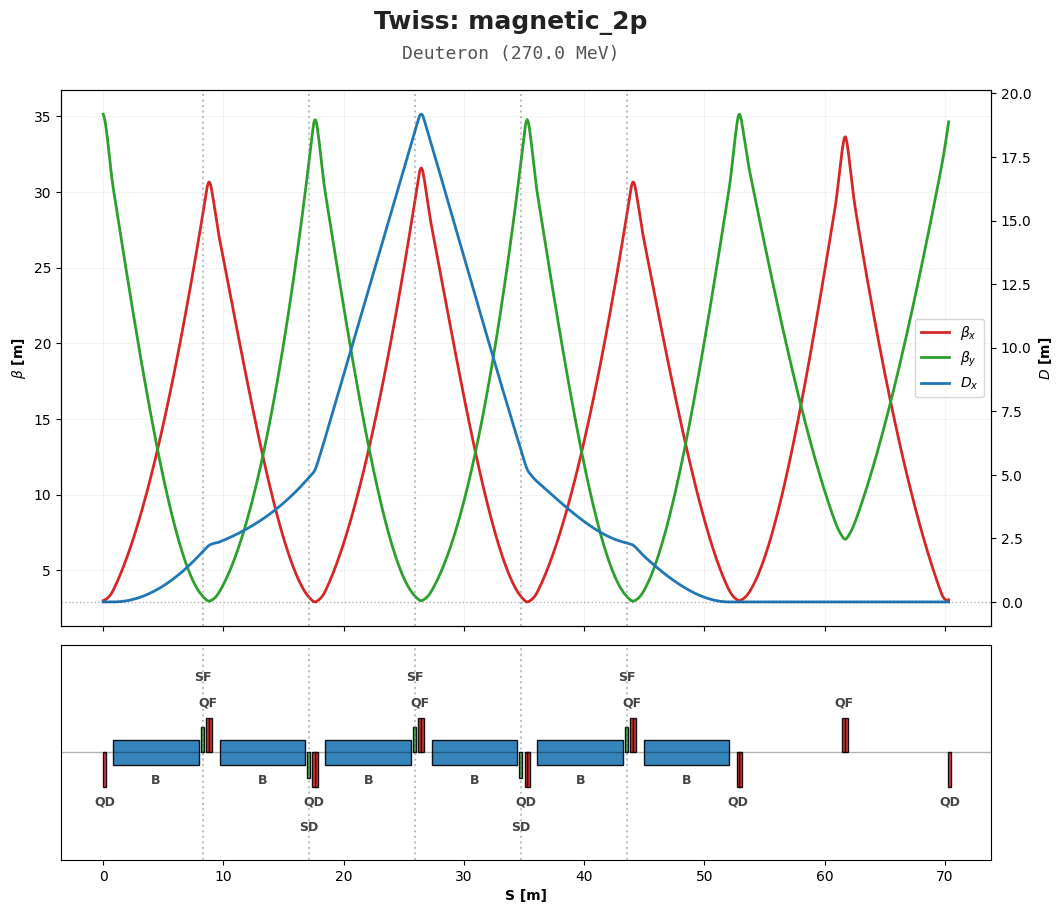

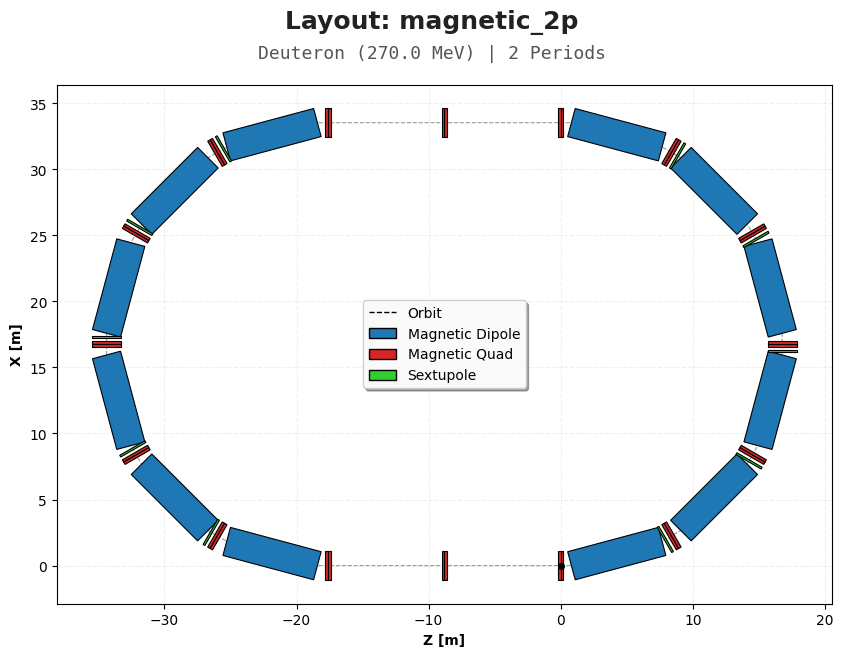

✅ Finished magnetic_2p

🚀 STARTING: magnetic_sextupoles
   -> Particle: Deuteron (270.0 MeV)
   -> Layout: 5 periods
   -> Found source: magnetic_sextupoles.fox
   📂 Reading data from: C:/GIT_REPOS/SCT/COSY/src/dat/magnetic_sextupoles
      ✅ BETAX: loaded 48 points
      ✅ BETAY: loaded 48 points
      ✅ DISPX: loaded 48 points
   -> Optics loaded successfully.
   -> Plotting...


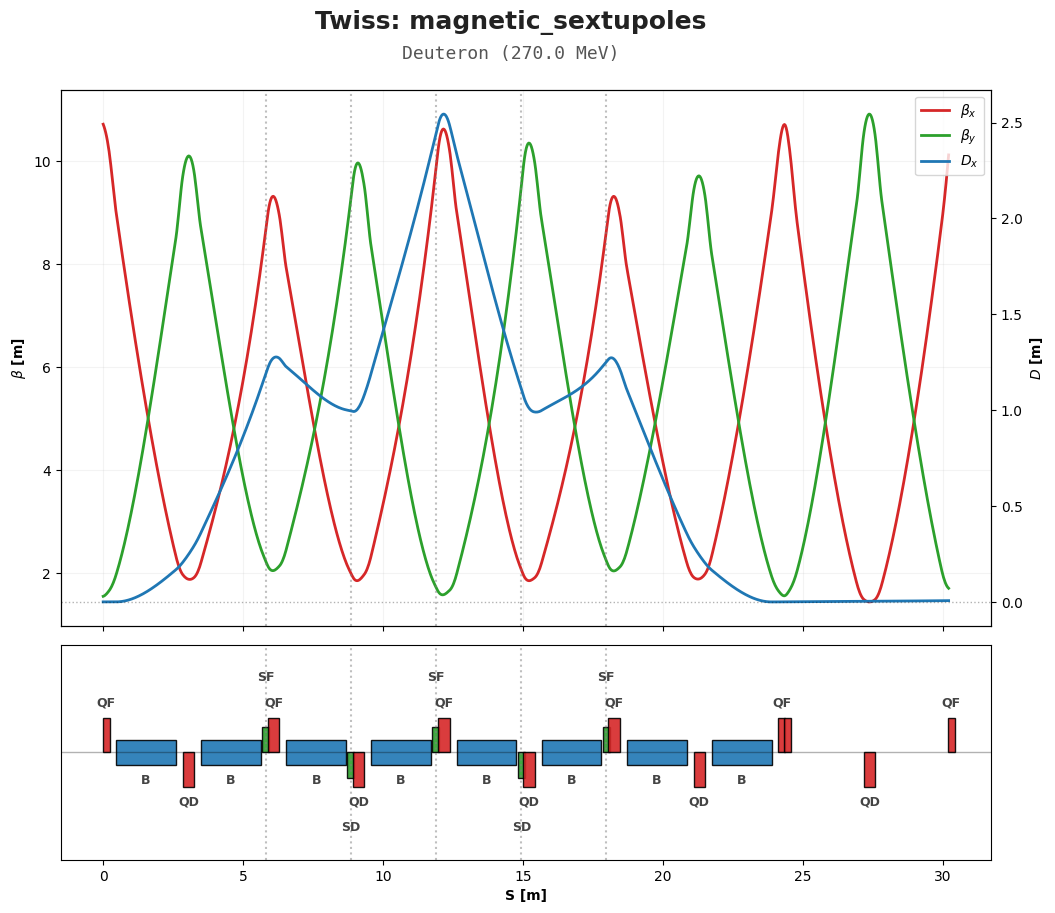

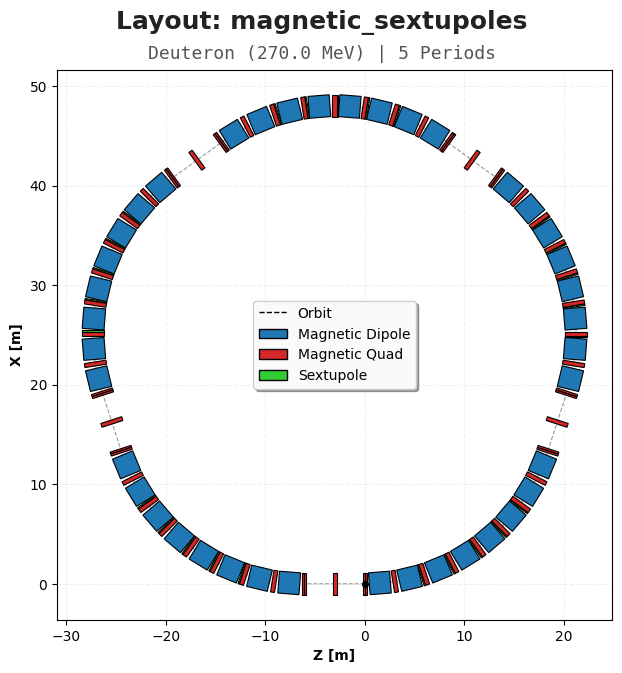

✅ Finished magnetic_sextupoles

🚀 STARTING: magnetic_mod
   -> Particle: Deuteron (270.0 MeV)
   -> Layout: 2 periods
   -> Found source: magnetic_mod.fox
   📂 Reading data from: C:/GIT_REPOS/SCT/COSY/src/dat/magnetic_mod
      ✅ BETAX: loaded 48 points
      ✅ BETAY: loaded 48 points
      ✅ DISPX: loaded 48 points
   -> Optics loaded successfully.
   -> Plotting...


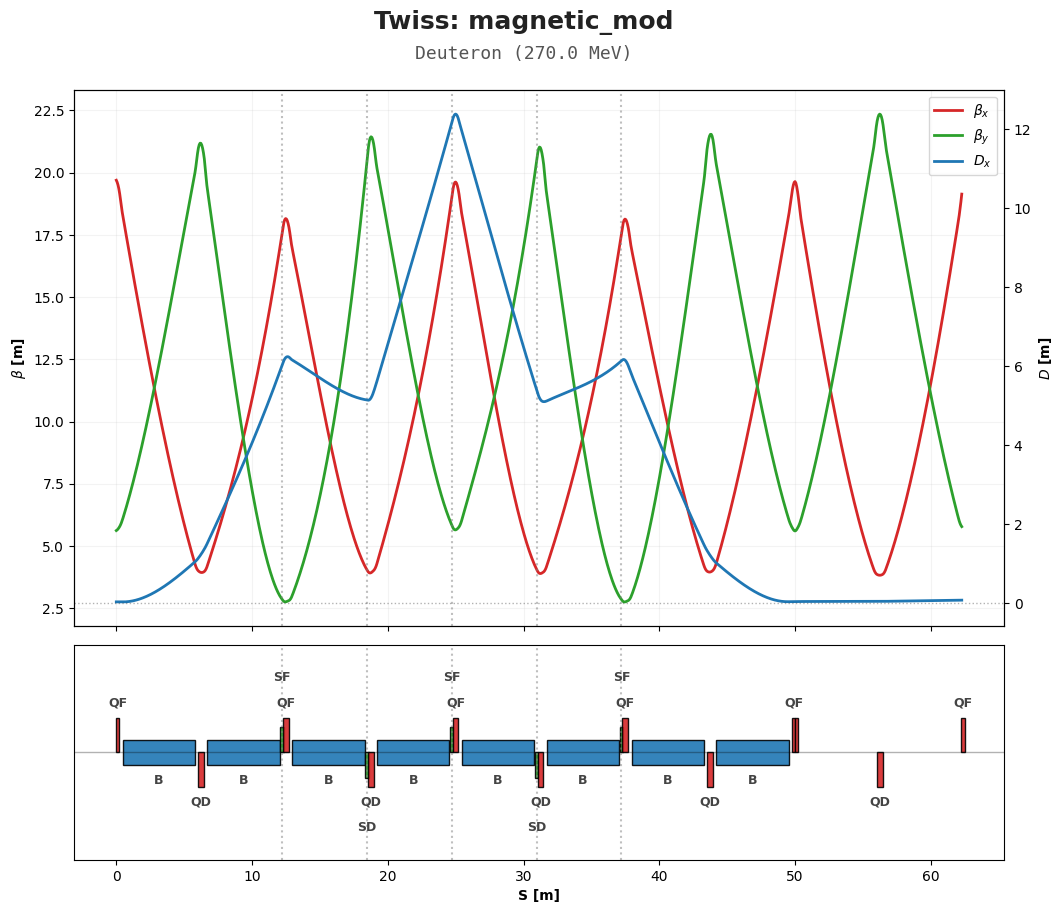

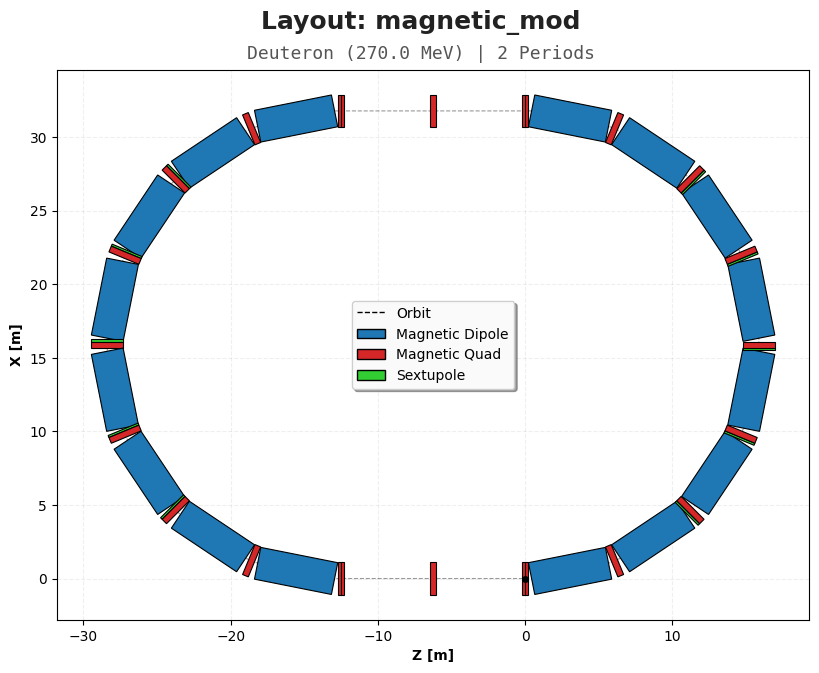

✅ Finished magnetic_mod

🚀 STARTING: electrostatic
   -> Particle: Proton (233.0 MeV)
   -> Layout: 5 periods
   -> Found source: electrostatic.fox
   📂 Reading data from: C:/GIT_REPOS/SCT/COSY/src/dat/electrostatic
      ✅ BETAX: loaded 58 points
      ✅ BETAY: loaded 58 points
      ✅ DISPX: loaded 58 points
   -> Optics loaded successfully.
   -> Plotting...


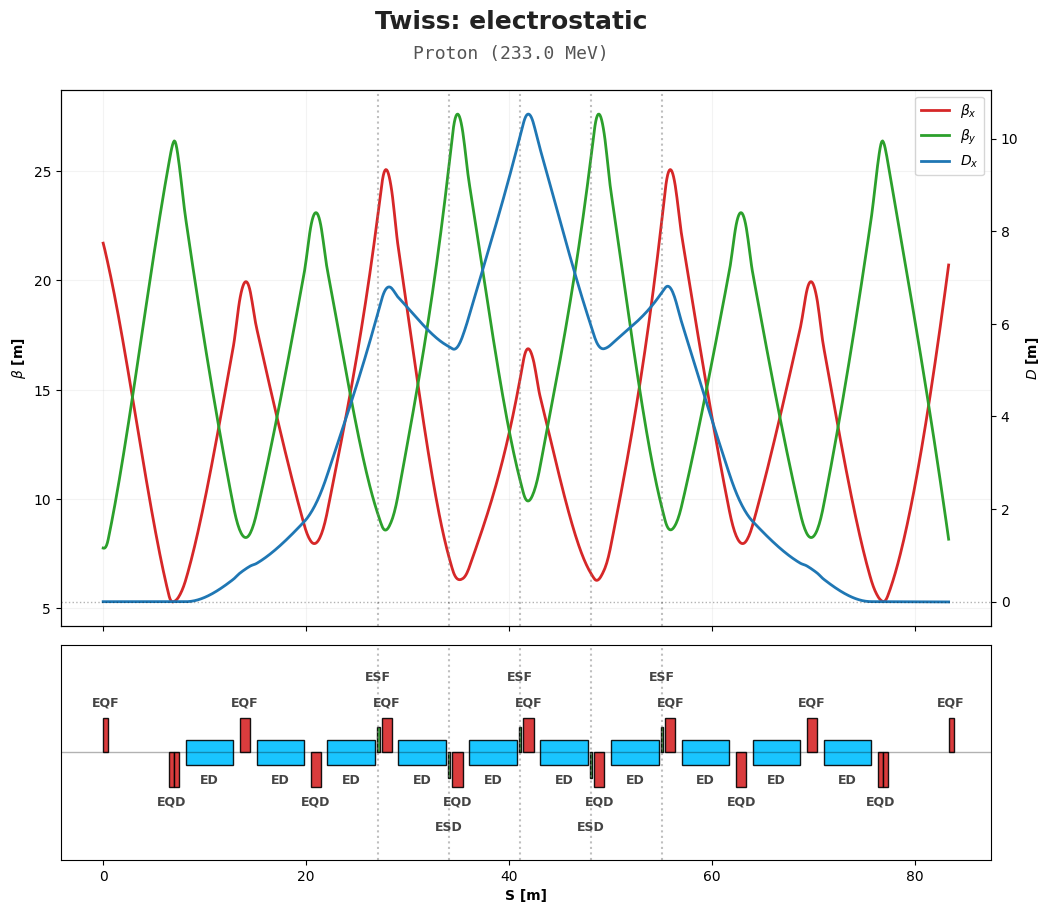

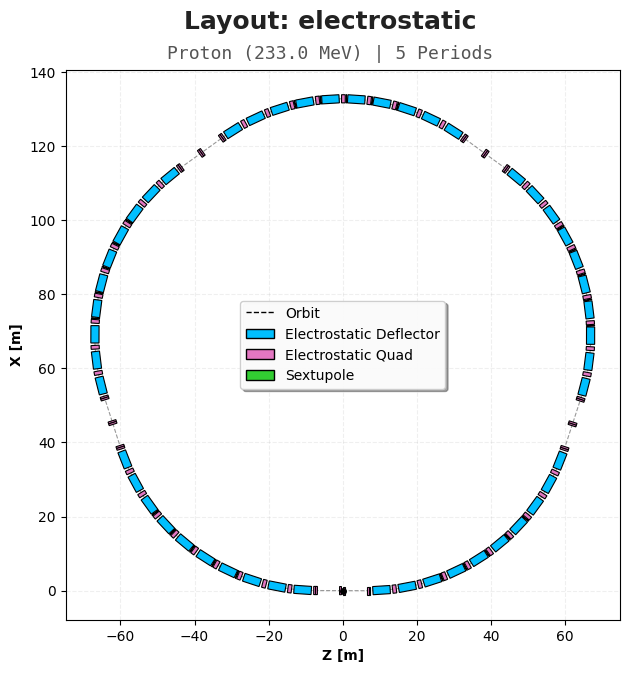

✅ Finished electrostatic

🚀 STARTING: Nuclotron_8
   -> Particle: Deuteron (270.0 MeV)
   -> Layout: 8 periods
   -> Found source: Nuclotron_8.fox
   📂 Reading data from: C:/GIT_REPOS/SCT/COSY/src/dat/Nuclotron_8
      ✅ BETAX: loaded 46 points
      ✅ BETAY: loaded 46 points
      ✅ DISPX: loaded 46 points
   -> Optics loaded successfully.
   -> Plotting...


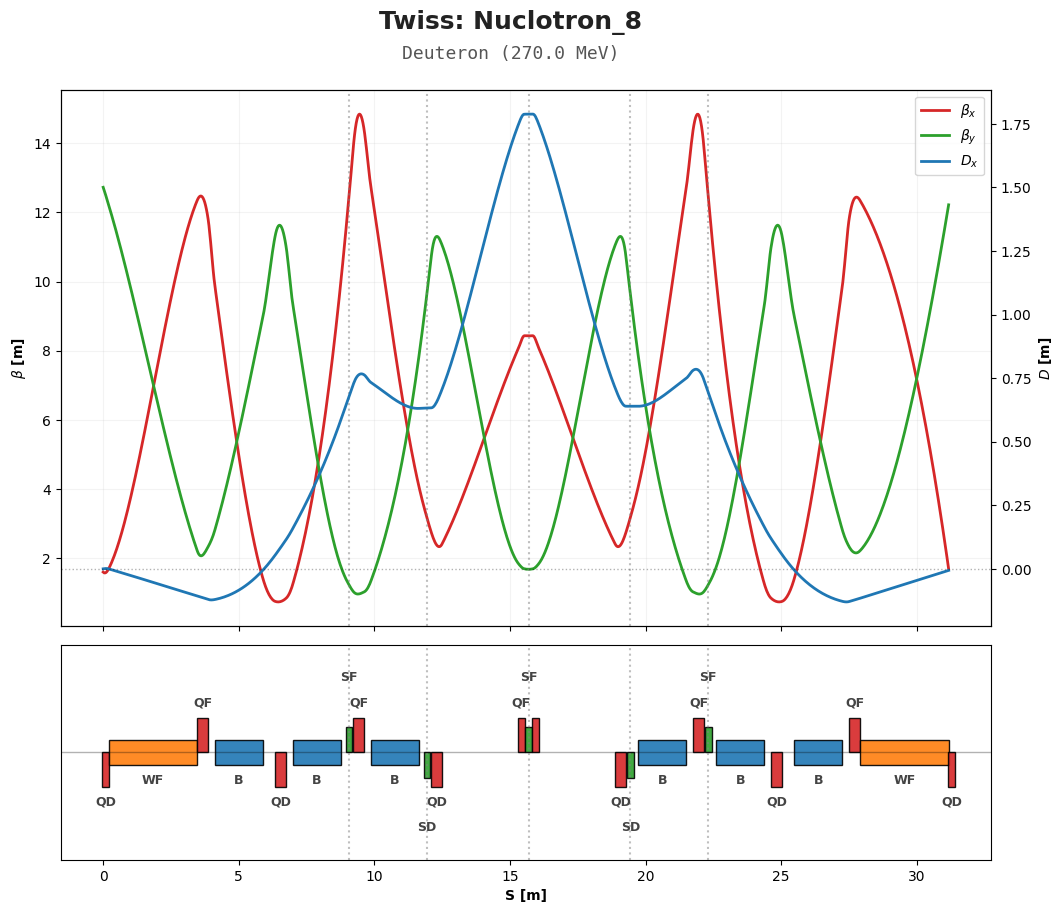

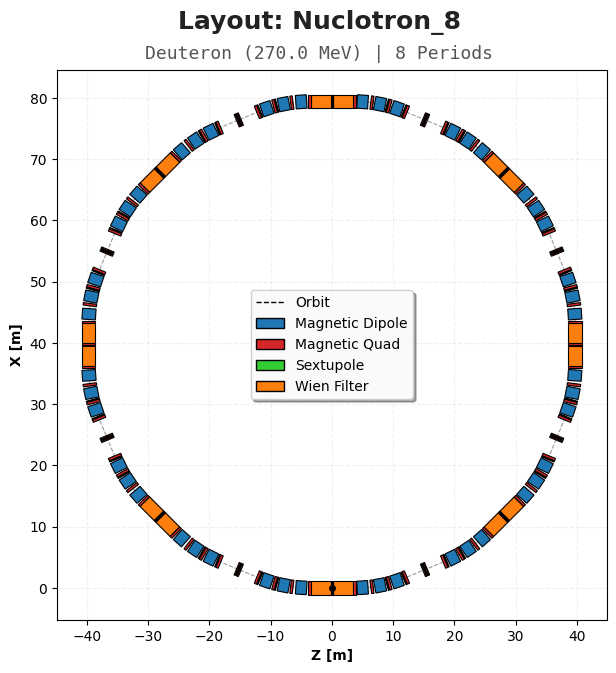

✅ Finished Nuclotron_8

🚀 STARTING: Nuclotron_16
   -> Particle: Deuteron (270.0 MeV)
   -> Layout: 8 periods
   -> Found source: Nuclotron_16.fox
   📂 Reading data from: C:/GIT_REPOS/SCT/COSY/src/dat/Nuclotron_16
      ✅ BETAX: loaded 48 points
      ✅ BETAY: loaded 48 points
      ✅ DISPX: loaded 48 points
   -> Optics loaded successfully.
   -> Plotting...


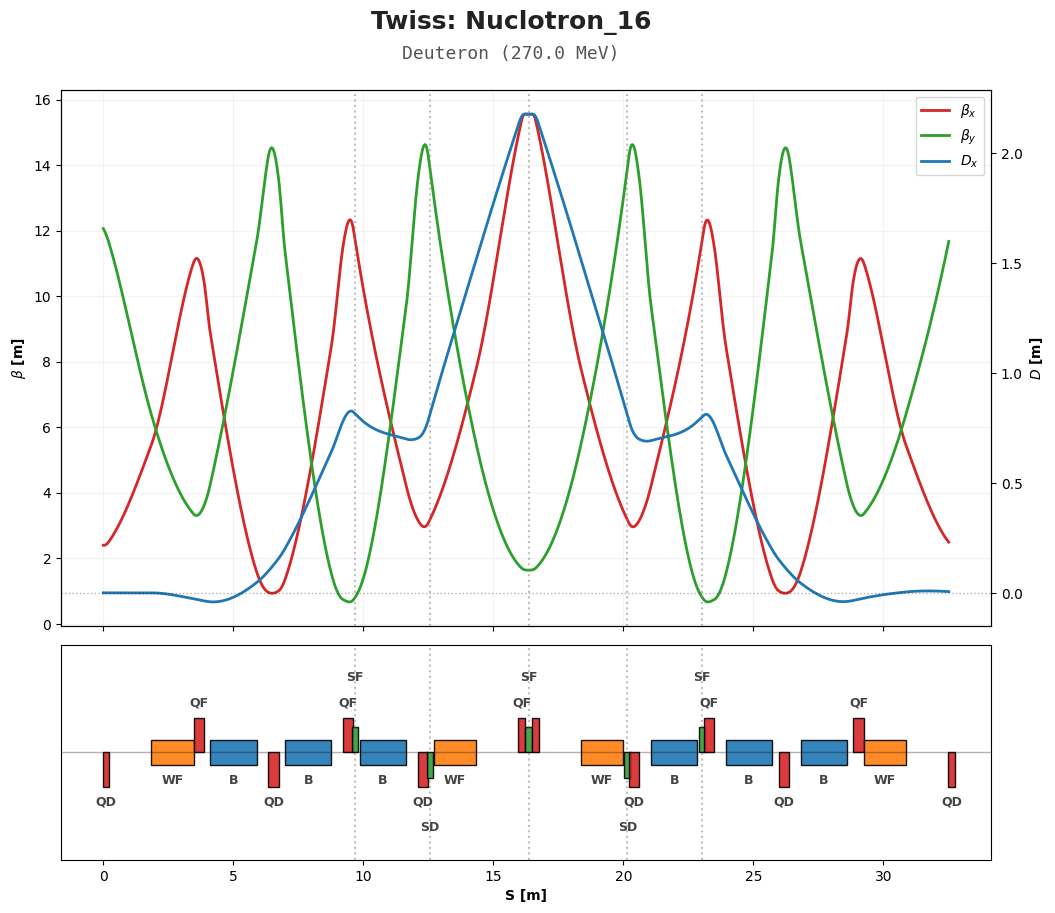

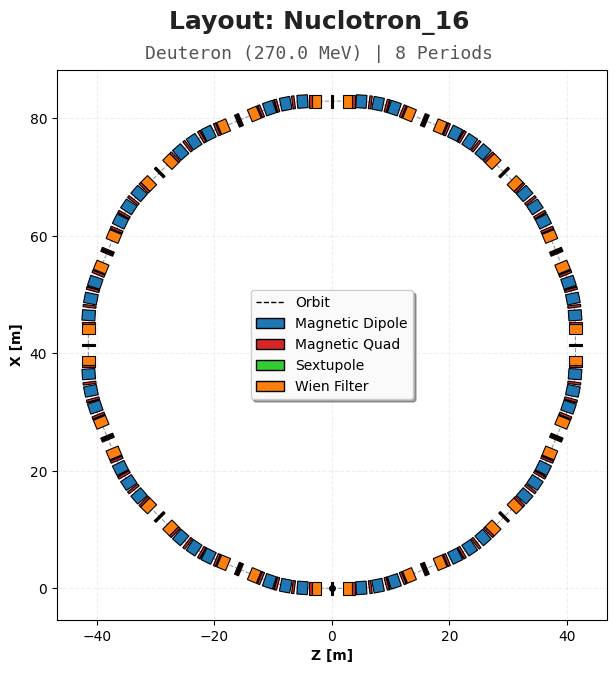

✅ Finished Nuclotron_16


In [24]:
import os

# ==============================================================================
# 1. НАСТРОЙКИ ПУТЕЙ
# ==============================================================================
ROOT_DIR = 'C:/GIT_REPOS/SCT/COSY/src/'
ROOT_DAT = os.path.join(ROOT_DIR, 'dat/')

# ==============================================================================
# 2. БАЗА ДАННЫХ КОНФИГУРАЦИЙ (ПАСПОРТА МАШИН)
# ==============================================================================
# Здесь мы задаем уникальные параметры для каждого кольца.

LATTICE_DB = {
    # --- 1. Magnetic Ring (2 Periods) ---
    'magnetic_2p': {
        'particle': Deuteron(270.0),
        'n_periods': 2,
        'inputs': {
            'EB1': 112.464392, 
            'RFFLAG': 0, 'A': 0.05,
            'SEXTGx1': 0.1, 'SEXTGx2': 0.1, 
            'SEXTGy1': -0.1, 'SEXTGy2': -0.1
        }
    },

    # --- 2. Magnetic with Sextupoles ---
    'magnetic_sextupoles': {
        'particle': Deuteron(270.0),
        'n_periods': 5,
        'inputs': {
            'EB1': 0.0,
            'SEXTGx1': 0.1, 'SEXTGx2': 0.1, 
            'SEXTGy1': -0.1, 'SEXTGy2': -0.1,
            'RFFLAG': 0, 'A': 0.05
        }
    },
    
        # --- 2. Magnetic Modified with Sextupoles ---
    'magnetic_mod': {
        'particle': Deuteron(270.0),
        'n_periods': 2,
        'inputs': {
            'EB1': 0.0,
            'SEXTGx1': 0.1, 'SEXTGx2': 0.1, 
            'SEXTGy1': -0.1, 'SEXTGy2': -0.1,
            'RFFLAG': 0, 'A': 0.05
        }
    },

    # --- 3. Electrostatic Ring ---
    'electrostatic': {
        'particle': Proton(233.0),
        'n_periods': 5,
        'inputs': {
            'EB1': 112.464392,
            'SEXTGx1': 0.1, 'SEXTGx2': 0.1, 
            'SEXTGy1': -0.1, 'SEXTGy2': -0.1,
            'RFFLAG': 0, 'A': 0.05
        }
    },

    # --- 4. Nuclotron (8 Periods) ---
    'Nuclotron_8': {
        'particle': Deuteron(270.0),
        'n_periods': 8,
        'inputs': {
            'EB1': 132, 
            'RFFLAG': 0, 'A': 0.05,
            'SEXTGx1': 0.1, 'SEXTGx2': 0.1, 
            'SEXTGy1': -0.1, 'SEXTGy2': -0.1
        }
    },

    # --- 5. Nuclotron (16 Periods) ---
    'Nuclotron_16': {
        'particle': Deuteron(270.0),
        'n_periods': 8,
        'inputs': {
            'EB1': 132,
            'RFFLAG': 0, 'A': 0.05,
            'SEXTGx1': 0.1, 'SEXTGx2': 0.1, 
            'SEXTGy1': -0.1, 'SEXTGy2': -0.1
        }
    }
}

# ==============================================================================
# 3. ДВИЖОК ОБРАБОТКИ
# ==============================================================================
for lat_name, config in LATTICE_DB.items():
    print(f"\n{'='*80}")
    print(f"🚀 STARTING: {lat_name}")
    print(f"{'='*80}")
    
    # 1. Извлекаем параметры из конфига
    p = config['particle']
    n_per = config['n_periods']
    current_inputs = config['inputs']
    
    print(f"   -> Particle: {p.__class__.__name__} ({p.T} MeV)")
    print(f"   -> Layout: {n_per} periods")

    # 2. Поиск файла (Smart Lookup)
    # Проверяем name.fox и name_maps.fox
    candidates = [
        os.path.join(ROOT_DIR, f"{lat_name}.fox"),
        os.path.join(ROOT_DIR, f"{lat_name}_maps.fox")
    ]
    
    src_file = None
    for cand in candidates:
        if os.path.exists(cand):
            src_file = cand
            break
    
    if not src_file:
        print(f"❌ File not found. Checked: {[os.path.basename(c) for c in candidates]}")
        continue
    
    print(f"   -> Found source: {os.path.basename(src_file)}")

    # 3. Парсинг и Расчет
    try:
        parser = FoxParser(src_file, current_inputs)
        library, sequence = parser.parse()
        
        if not sequence:
            print("   ⚠️ Warning: Sequence is empty. Skipping plots.")
            continue

        # 4. Загрузка Оптики (DAT файлы)
        # Пытаемся найти DAT файл. Имя обычно совпадает с именем решетки.
        try:
            load_optics(sequence, ROOT_DAT, lat_name)
            print("   -> Optics loaded successfully.")
        except Exception as e:
            print(f"   ⚠️ Optics load skipped: {e}")
            print("      (Drawing Layout only)")

        # 5. Генерация Графиков
        print("   -> Plotting...")
        
        # График 1: Твисс-параметры
        twiss_plot =  plot_optics(sequence, particle=p, title=f"Twiss: {lat_name}")
        save_path_1 = os.path.join(ROOT_DIR, 'dat', lat_name, f"{lat_name}_twiss.png")
        twiss_plot.savefig(save_path_1, dpi=100, bbox_inches='tight')
        plt.show()
        # График 2: Геометрия кольца
        layout_plot = plot_floor_plan(sequence, particle=p, n_periods=n_per, title=f"Layout: {lat_name}")
        layout_plot.set_size_inches(10, 10)
        layout_plot.subplots_adjust(top=0.9, bottom=0.35)
        save_path_2 = os.path.join(ROOT_DIR, 'dat', lat_name, f"{lat_name}_layout.png")
        layout_plot.savefig(save_path_2, dpi=100, bbox_inches='tight')
        plt.show()
        
        print(f"✅ Finished {lat_name}")

    except Exception as e:
        print(f"❌ CRITICAL ERROR on {lat_name}: {e}")
        # import traceback; traceback.print_exc() 

In [12]:
import os

# ==============================================================================
# ИНСПЕКТОР ПАРАМЕТРОВ (AUDIT TOOL)
# ==============================================================================

def safe_get(obj, attr, default=0.0):
    """Безопасное получение атрибута. Возвращает 0.0, если атрибут None."""
    val = getattr(obj, attr, default)
    return val if val is not None else default

def format_params(element):
    """Собирает строку параметров, игнорируя пустые значения."""
    props = []
    
    # 1. Геометрия
    angle = safe_get(element, 'angle')
    if abs(angle) > 1e-9:
        props.append(f"Ang={angle:.4f}")
        
    radius = safe_get(element, 'radius')
    if abs(radius) > 1e-9:
        props.append(f"R={radius:.3f}")
        
    aper = safe_get(element, 'aperture')
    if abs(aper) > 1e-9:
        props.append(f"Ap={aper:.1f}")

    # 2. Магнитные параметры
    k1 = safe_get(element, 'k1')
    if abs(k1) > 1e-9:
        props.append(f"K1={k1:.4f}")
        
    b_tip = safe_get(element, 'b_tip')
    if abs(b_tip) > 1e-9:
        props.append(f"B_tip={b_tip:.4f}")
        
    strength = safe_get(element, 'strength')
    if abs(strength) > 1e-9:
        props.append(f"Str={strength:.4f}")

    # 3. Электрические параметры
    volt = safe_get(element, 'voltage')
    if abs(volt) > 1e-9:
        props.append(f"U={volt:.1f}kV")
        
    e_field = safe_get(element, 'E_kVcm')
    if abs(e_field) > 1e-9:
        props.append(f"E={e_field:.2f}kV/cm")
    
    tilt = safe_get(element, 'tilt')
    if abs(tilt) > 1e-9:
        props.append(f"Tilt={tilt:.1f}")

    return ", ".join(props)

def inspect_lattices(db, root_dir):
    print(f"\n{'='*100}")
    print(f"🔬 LATTICE INSPECTOR")
    print(f"{'='*100}")

    for lat_name, config in db.items():
        print(f"\n📌 STRUCTURE: {lat_name.upper()}")
        
        # 1. Поиск файла
        src_file = os.path.join(root_dir, f"{lat_name}.fox")
        if not os.path.exists(src_file):
            src_file = os.path.join(root_dir, f"{lat_name}_maps.fox")
            
        if not os.path.exists(src_file):
            print(f"❌ ERROR: File not found for {lat_name}")
            continue

        # 2. Парсинг
        try:
            # Создаем парсер с глобальными переменными из конфига
            parser = FoxParser(src_file, config['inputs'])
            _, sequence = parser.parse()
            
            if not sequence:
                print("⚠️ Empty sequence.")
                continue

            # 3. Таблица
            print(f"{'ID':<4} | {'NAME':<18} | {'TYPE':<24} | {'L [m]':<8} | {'PARAMETERS'}")
            print("-" * 110)

            total_len = 0.0
            
            for i, slot in enumerate(sequence):
                el = slot.phys
                
                # Безопасное обновление физики (если метод есть)
                if hasattr(el, 'update_from_particle'):
                    try:
                        el.update_from_particle(config['particle'])
                    except:
                        pass # Игнорируем ошибки физики при инспекции
                
                # Получаем длину безопасно
                L = safe_get(el, 'L')
                
                # Пропускаем пустые маркеры (Drift L=0)
                if el.entity == "Drift" and L == 0:
                    continue
                    
                p_str = format_params(el)
                print(f"{i:<4} | {el.name:<18} | {el.entity:<24} | {L:<8.4f} | {p_str}")
                
                total_len += L

            print("-" * 110)
            print(f"🏁 Period Length: {total_len:.4f} m")
            print(f"⭕ Total Length ({config['n_periods']}x): {total_len * config['n_periods']:.4f} m")

        except Exception as e:
            print(f"❌ Parse Error in {lat_name}: {e}")

# --- ЗАПУСК ---
inspect_lattices(LATTICE_DB, ROOT_DIR)


🔬 LATTICE INSPECTOR

📌 STRUCTURE: MAGNETIC_2P
ID   | NAME               | TYPE                     | L [m]    | PARAMETERS
--------------------------------------------------------------------------------------------------------------
0    | QD                 | Quadrupole               | 0.2000   | K1=-0.4925
1    | O4                 | Drift                    | 0.6500   | 
2    | BM                 | Dipole                   | 7.1059   | Ang=0.5236
3    | O2                 | Drift                    | 0.2500   | 
4    | SEXT               | Sextupole                | 0.1500   | Ap=0.1, Str=0.1000
5    | O2                 | Drift                    | 0.2500   | 
6    | QF                 | Quadrupole               | 0.2100   | K1=0.3999
7    | QF                 | Quadrupole               | 0.2100   | K1=0.3999
8    | O4                 | Drift                    | 0.6500   | 
9    | BM                 | Dipole                   | 7.1059   | Ang=0.5236
10   | O2                 | D